In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


from sklearn.decomposition import PCA

import seaborn as sns
from sklearn.manifold import TSNE

import lissa as li

In [2]:
entireData = pd.read_csv("../data/totalProcessedData.csv")
entireData.drop(columns="Unnamed: 0",inplace=True)

/tmp/ipykernel_445199/1122376188.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  entireData = pd.read_csv("../data/totalProcessedData.csv")


In [3]:
entireData["Failure"]=entireData["Failure"].astype(bool)

entireData["time"] = pd.to_datetime(entireData["index"])
entireData.set_index("time",inplace=True)
entireData.drop(columns="index",inplace=True)

pumpList = entireData["Well Run"].unique()

[0.29644778 0.44690002 0.56856813 0.67259535 0.75397415 0.82447934
 0.88291838 0.92686305 0.96101815 0.98969518 1.        ]


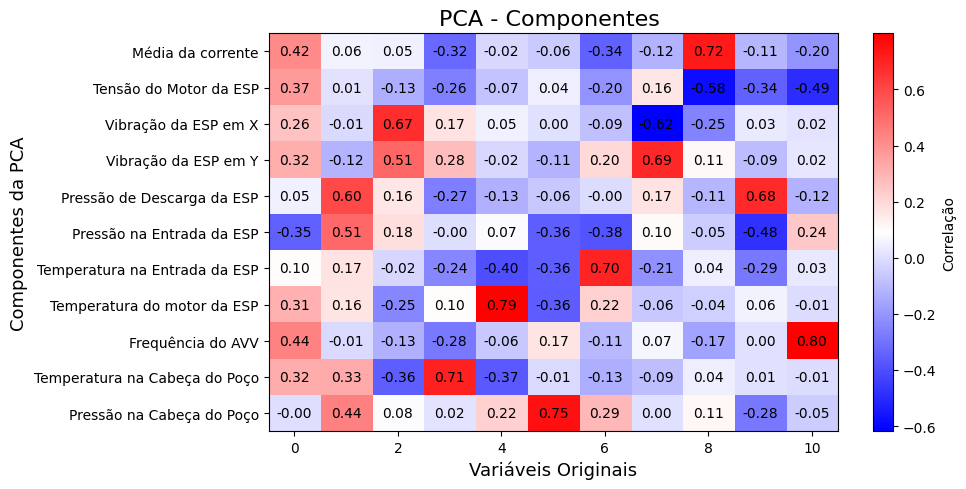

In [4]:
n = 11

operationalHeaders = li.operationalHeader(entireData)

pca = li.ApplyPCA(entireData, n)
fig,axs = li.FigureComponents(pca,operationalHeaders, 
                              listOfNames=["PCA - Componentes ", "Correlação", "Variáveis Originais","Componentes da PCA"],
                              plotName="full_pca_pt",
                              english=False)
PCAdata = li.ReducePCA(pca, n, operationalHeaders,entireData)


PCAHeaders = [str(i) for i in range(0,n)]
PCAdata = li.ExportPCAData(PCAdata,entireData)


[0.29644778 0.44690002 0.56856813 0.67259535 0.75397415 0.82447934
 0.88291838 0.92686305 0.96101815 0.98969518 1.        ]


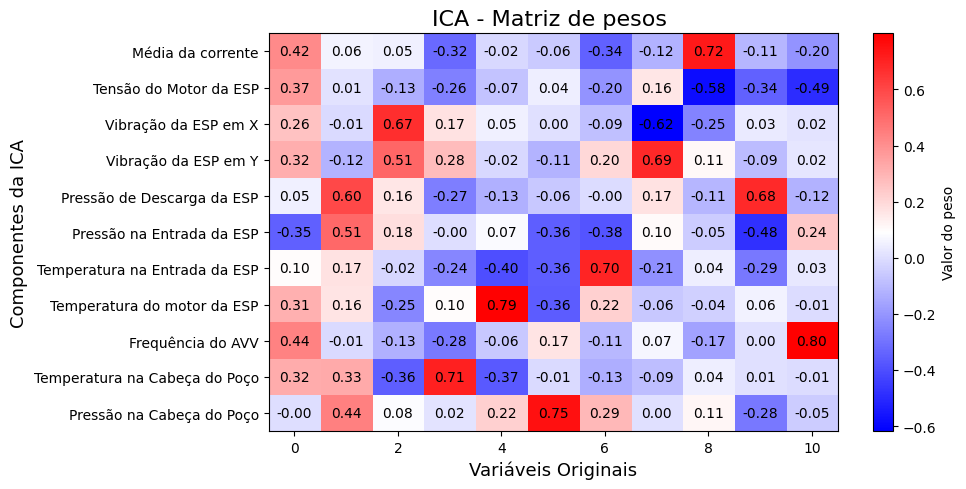

In [5]:
n =11

operationalHeaders = li.operationalHeader(entireData)

ica = li.ApplyICA(entireData, n)

fig,axs = li.FigureComponents(pca,operationalHeaders, 
                              listOfNames=["ICA - Matriz de pesos ", "Valor do peso", "Variáveis Originais","Componentes da ICA"],
                              plotName="full_ica_pt",
                              english=False)

ICAdata = li.ReduceICA(ica, n, operationalHeaders,entireData)


ICAHeaders = [str(i) for i in range(0,n)]
ICAdata = li.ExportPCAData(ICAdata,entireData)

Text(0.5, 1.0, 'B-18 2 - Standardized Data')

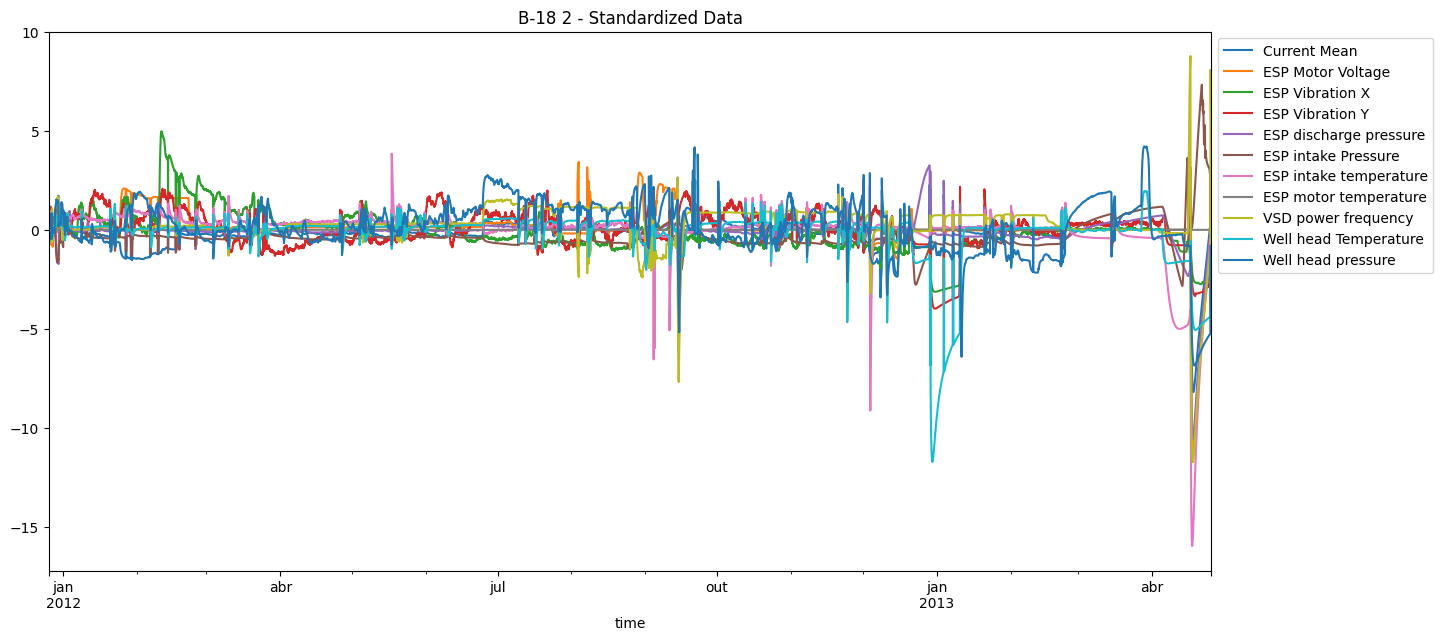

In [6]:
pump = pumpList[0]

entireData.loc[entireData["Well Run"]==pump][operationalHeaders].plot(figsize=(15,7))
plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)
plt.title(pump + " - Standardized Data")



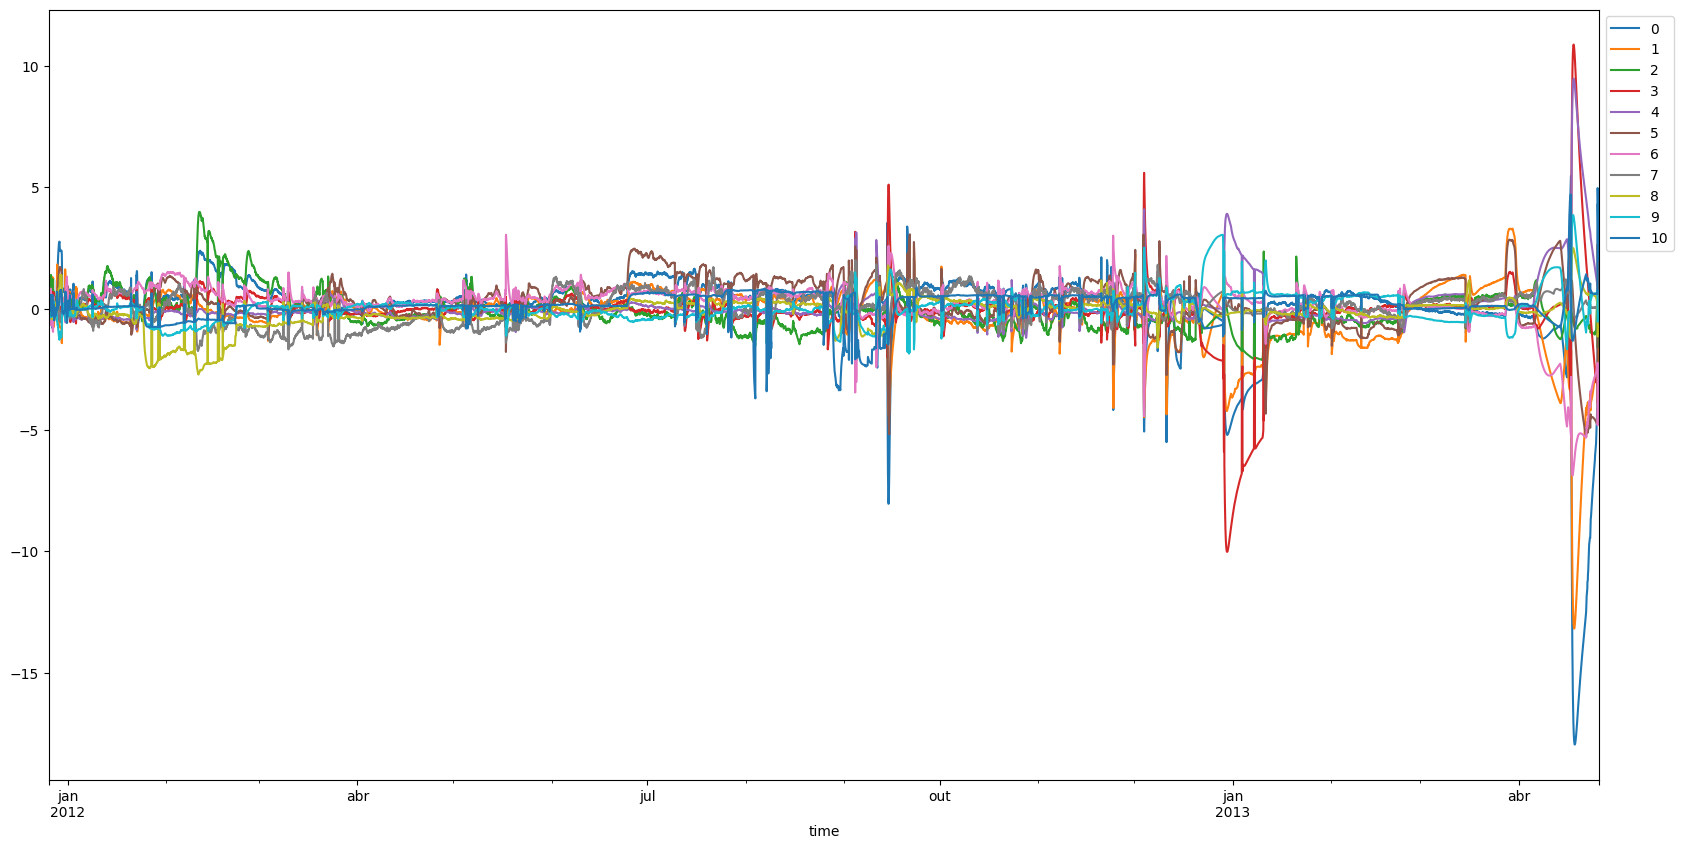

In [7]:
PCAdata.loc[PCAdata["Well Run"]==pump][PCAHeaders].plot(figsize=(20,10))
plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=10)


<Axes: xlabel='time'>

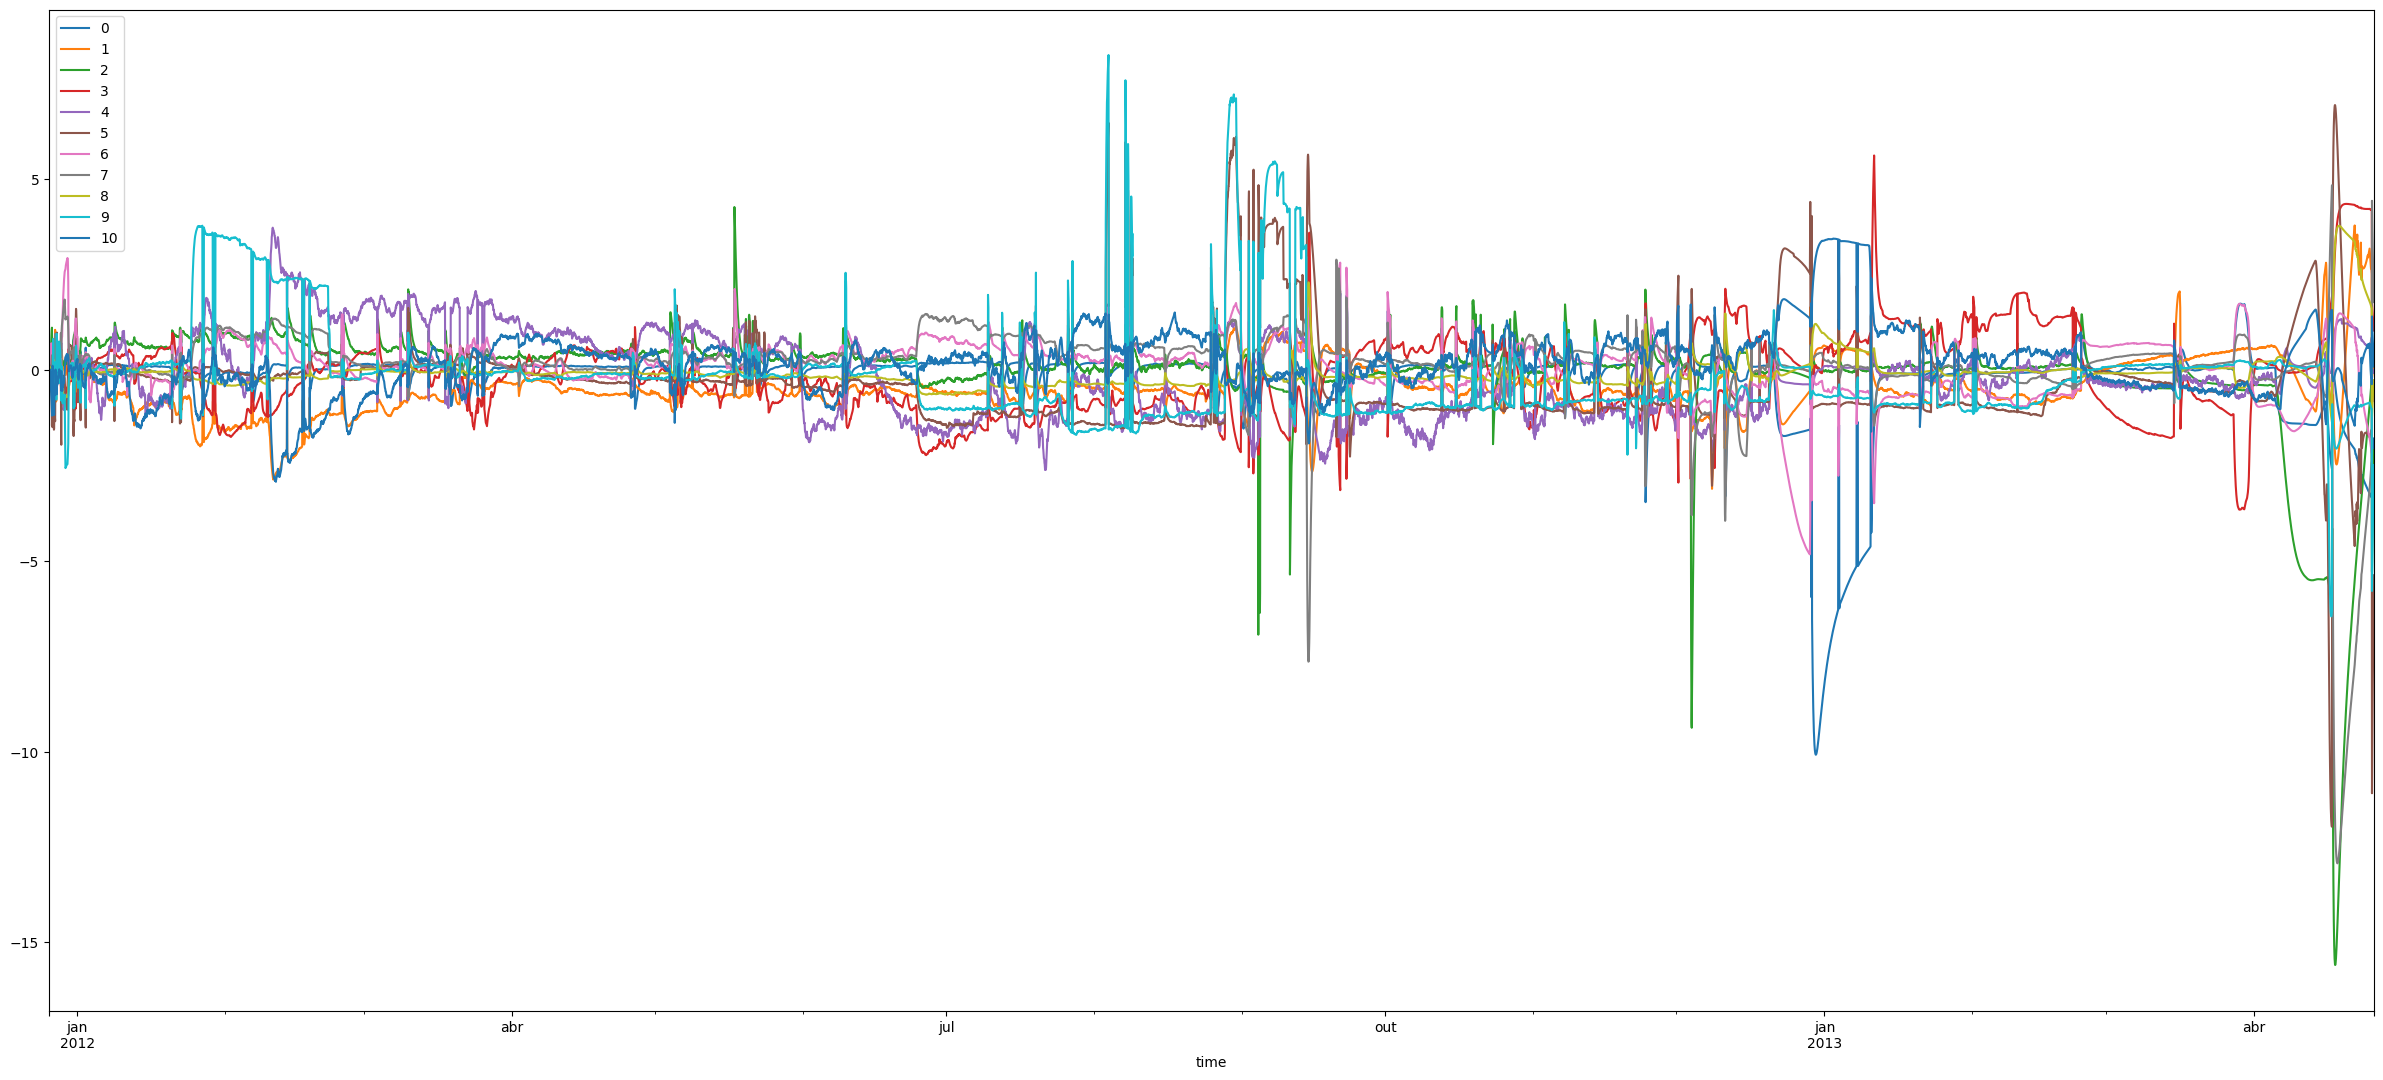

In [8]:
ICAdata.loc[ICAdata["Well Run"]==pumpList[0]][ICAHeaders].plot(figsize=(30,13))

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: title={'center': '5'}>],
       [<Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>,
        <Axes: title={'center': '8'}>],
       [<Axes: title={'center': '9'}>, <Axes: title={'center': '10'}>,
        <Axes: >]], dtype=object)

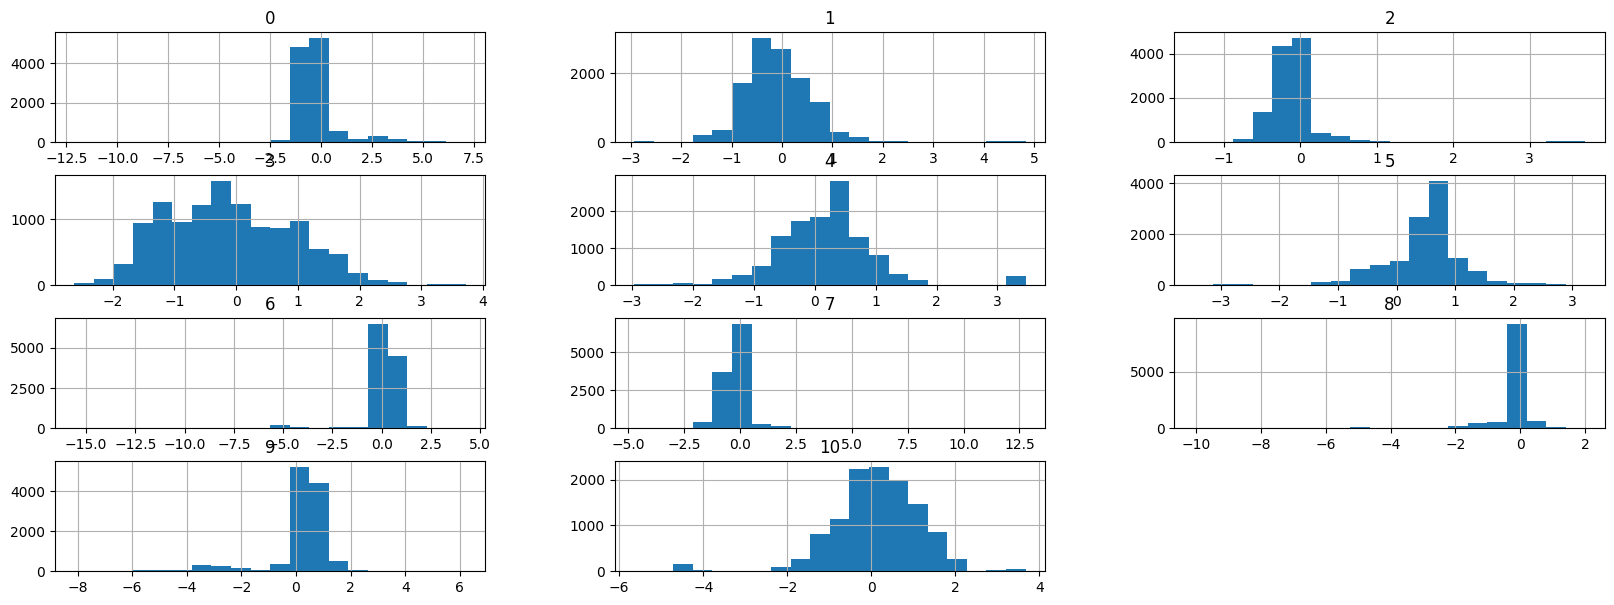

In [13]:
ICAdata.loc[ICAdata["Well Run"]==pumpList[0]][ICAHeaders].hist(bins=20,figsize=(20,7))

<Axes: >

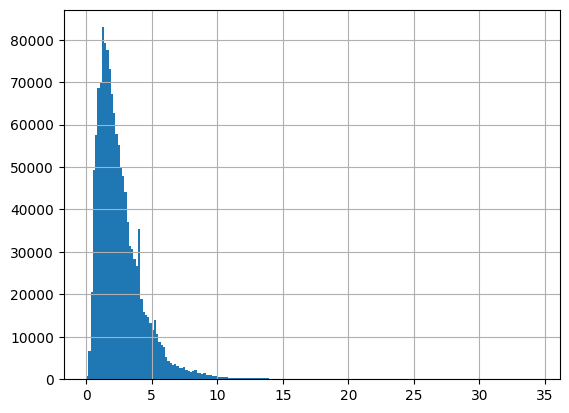

In [15]:
PCAdata[PCAHeaders].pow(2).sum(axis=1).pow(1/2).hist(bins=200)

<Axes: >

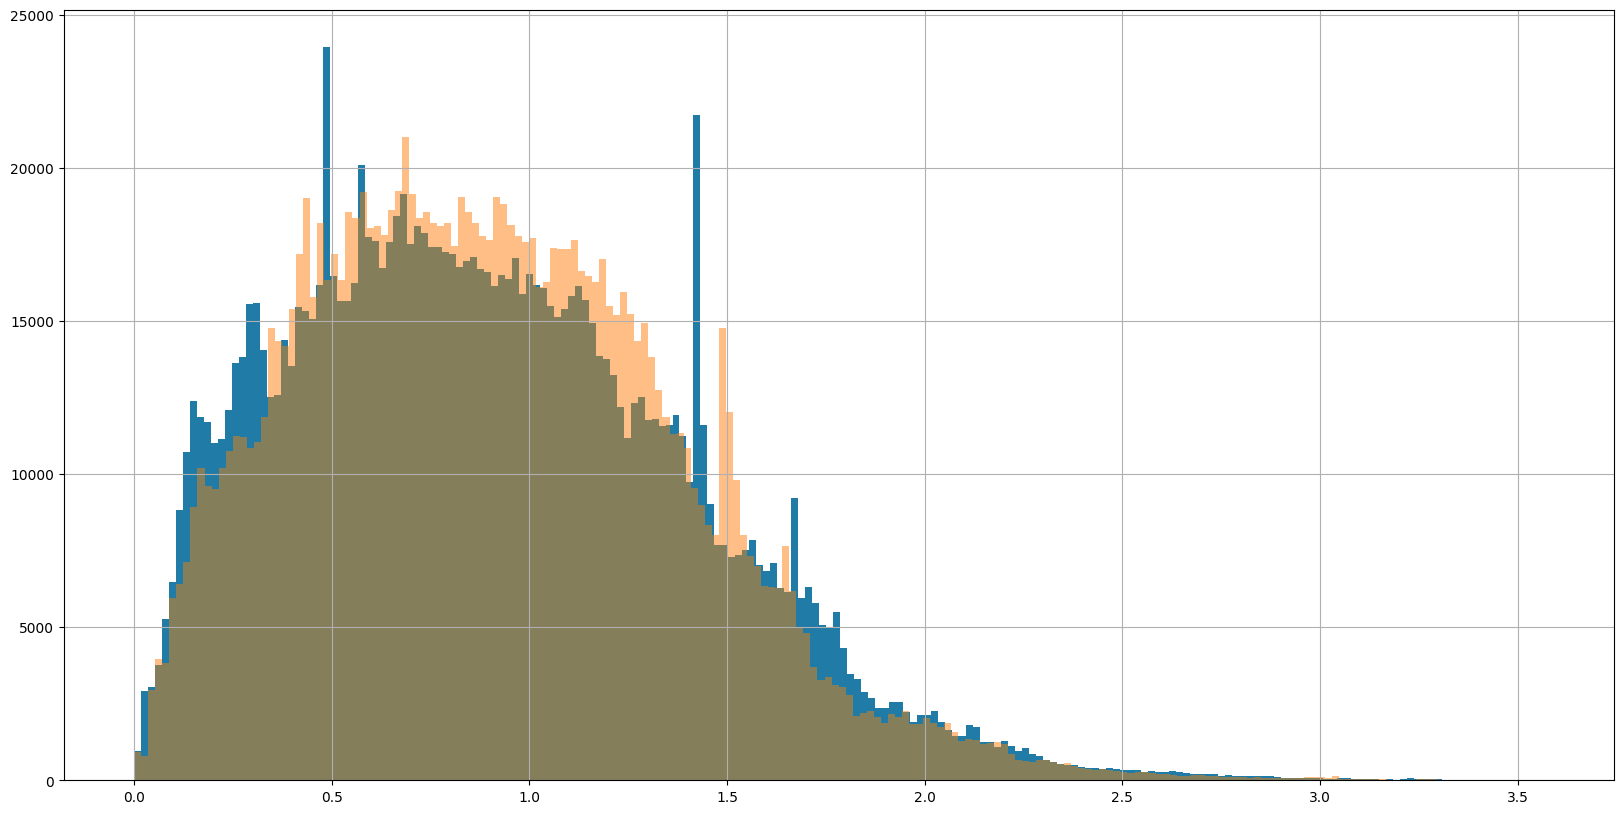

In [14]:
entireData[operationalHeaders].pow(2).sum(axis=1).apply(lambda x: np.log1p(x)/2).hist(bins=200,figsize=(20,10),alpha=1) #.pow(1/2) .apply(lambda x: np.log1p(x)/2)
ICAdata[ICAHeaders].pow(2).sum(axis=1).apply(lambda x: np.log1p(x)/2).hist(bins=200,figsize=(20,10),alpha=0.5)
PCAdata[PCAHeaders].pow(2).sum(axis=1).apply(lambda x: np.log1p(x)/2).hist(bins=200,figsize=(20,10),alpha=0.1)

array([[<Axes: title={'center': 'Current Mean'}>,
        <Axes: title={'center': 'ESP Motor Voltage'}>,
        <Axes: title={'center': 'ESP Vibration X'}>],
       [<Axes: title={'center': 'ESP Vibration Y'}>,
        <Axes: title={'center': 'ESP discharge pressure'}>,
        <Axes: title={'center': 'ESP intake Pressure'}>],
       [<Axes: title={'center': 'ESP intake temperature'}>,
        <Axes: title={'center': 'ESP motor temperature'}>,
        <Axes: title={'center': 'VSD power frequency'}>],
       [<Axes: title={'center': 'Well head Temperature'}>,
        <Axes: title={'center': 'Well head pressure'}>, <Axes: >]],
      dtype=object)

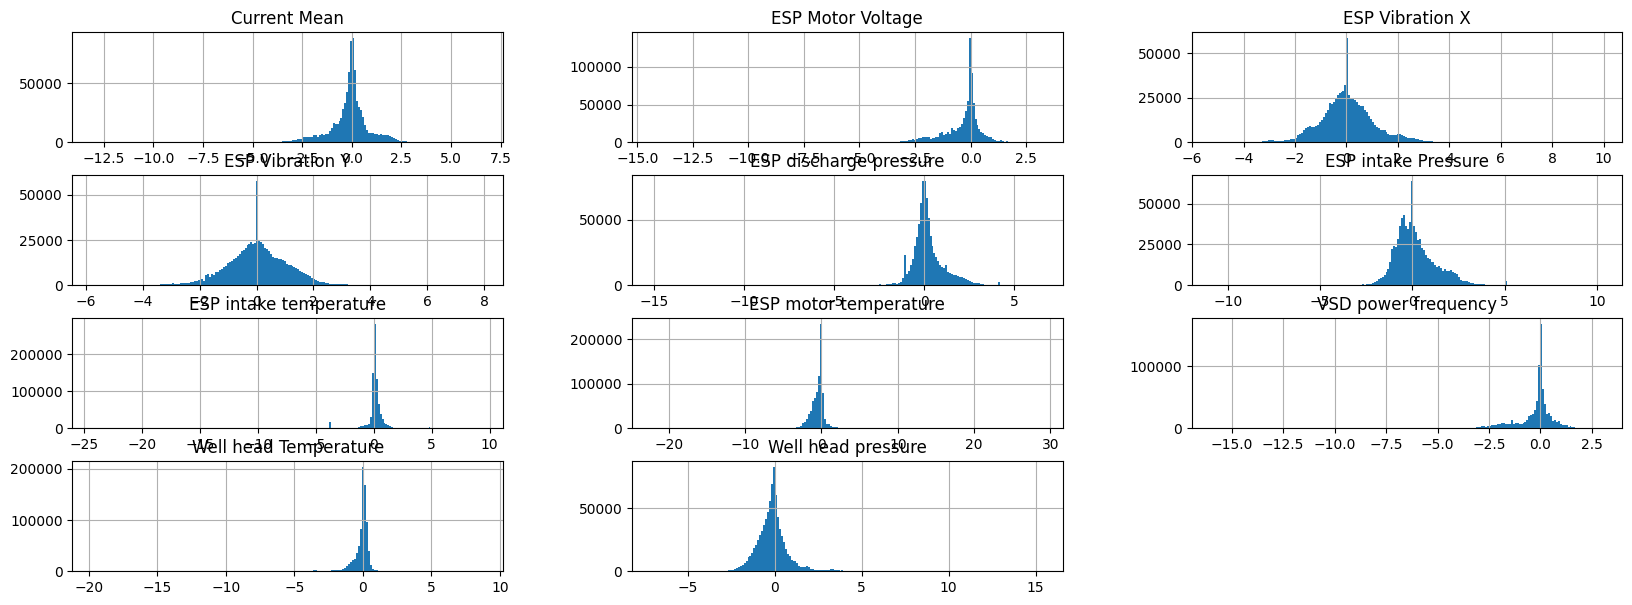

In [15]:
entireData.loc[entireData["Well_down"]==0][operationalHeaders].hist(bins=200,figsize=(20,7))

In [12]:
pumpData.loc[pumpData["Well_down"]==0].shape

NameError: name 'pumpData' is not defined

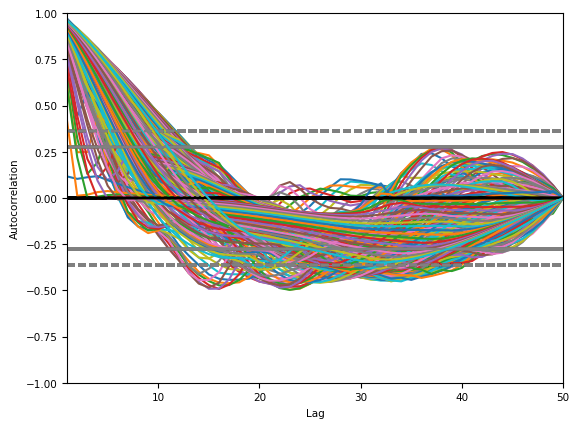

In [ ]:
for t in range(8800,9000):
    pd.plotting.autocorrelation_plot(pumpData["Radius"].loc[pumpData["Well_down"]==0].iloc[t:t+50])#.diff().fillna(0))

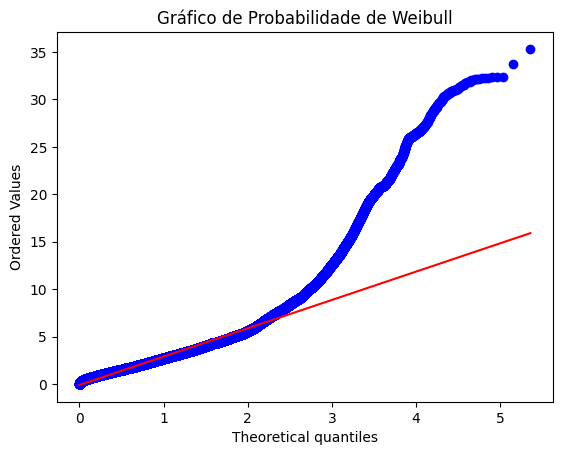

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

data = ICAdata["Radius"].to_numpy()

# Ajustar os parâmetros da Weibull
shape, loc, scale = stats.weibull_min.fit(data, floc=0)  # Força loc=0 para estabilidade

# Criar o gráfico de probabilidade
fig, ax = plt.subplots()
stats.probplot(data, dist="weibull_min", sparams=(shape,), plot=ax)
plt.title("Gráfico de Probabilidade de Weibull")
plt.show()


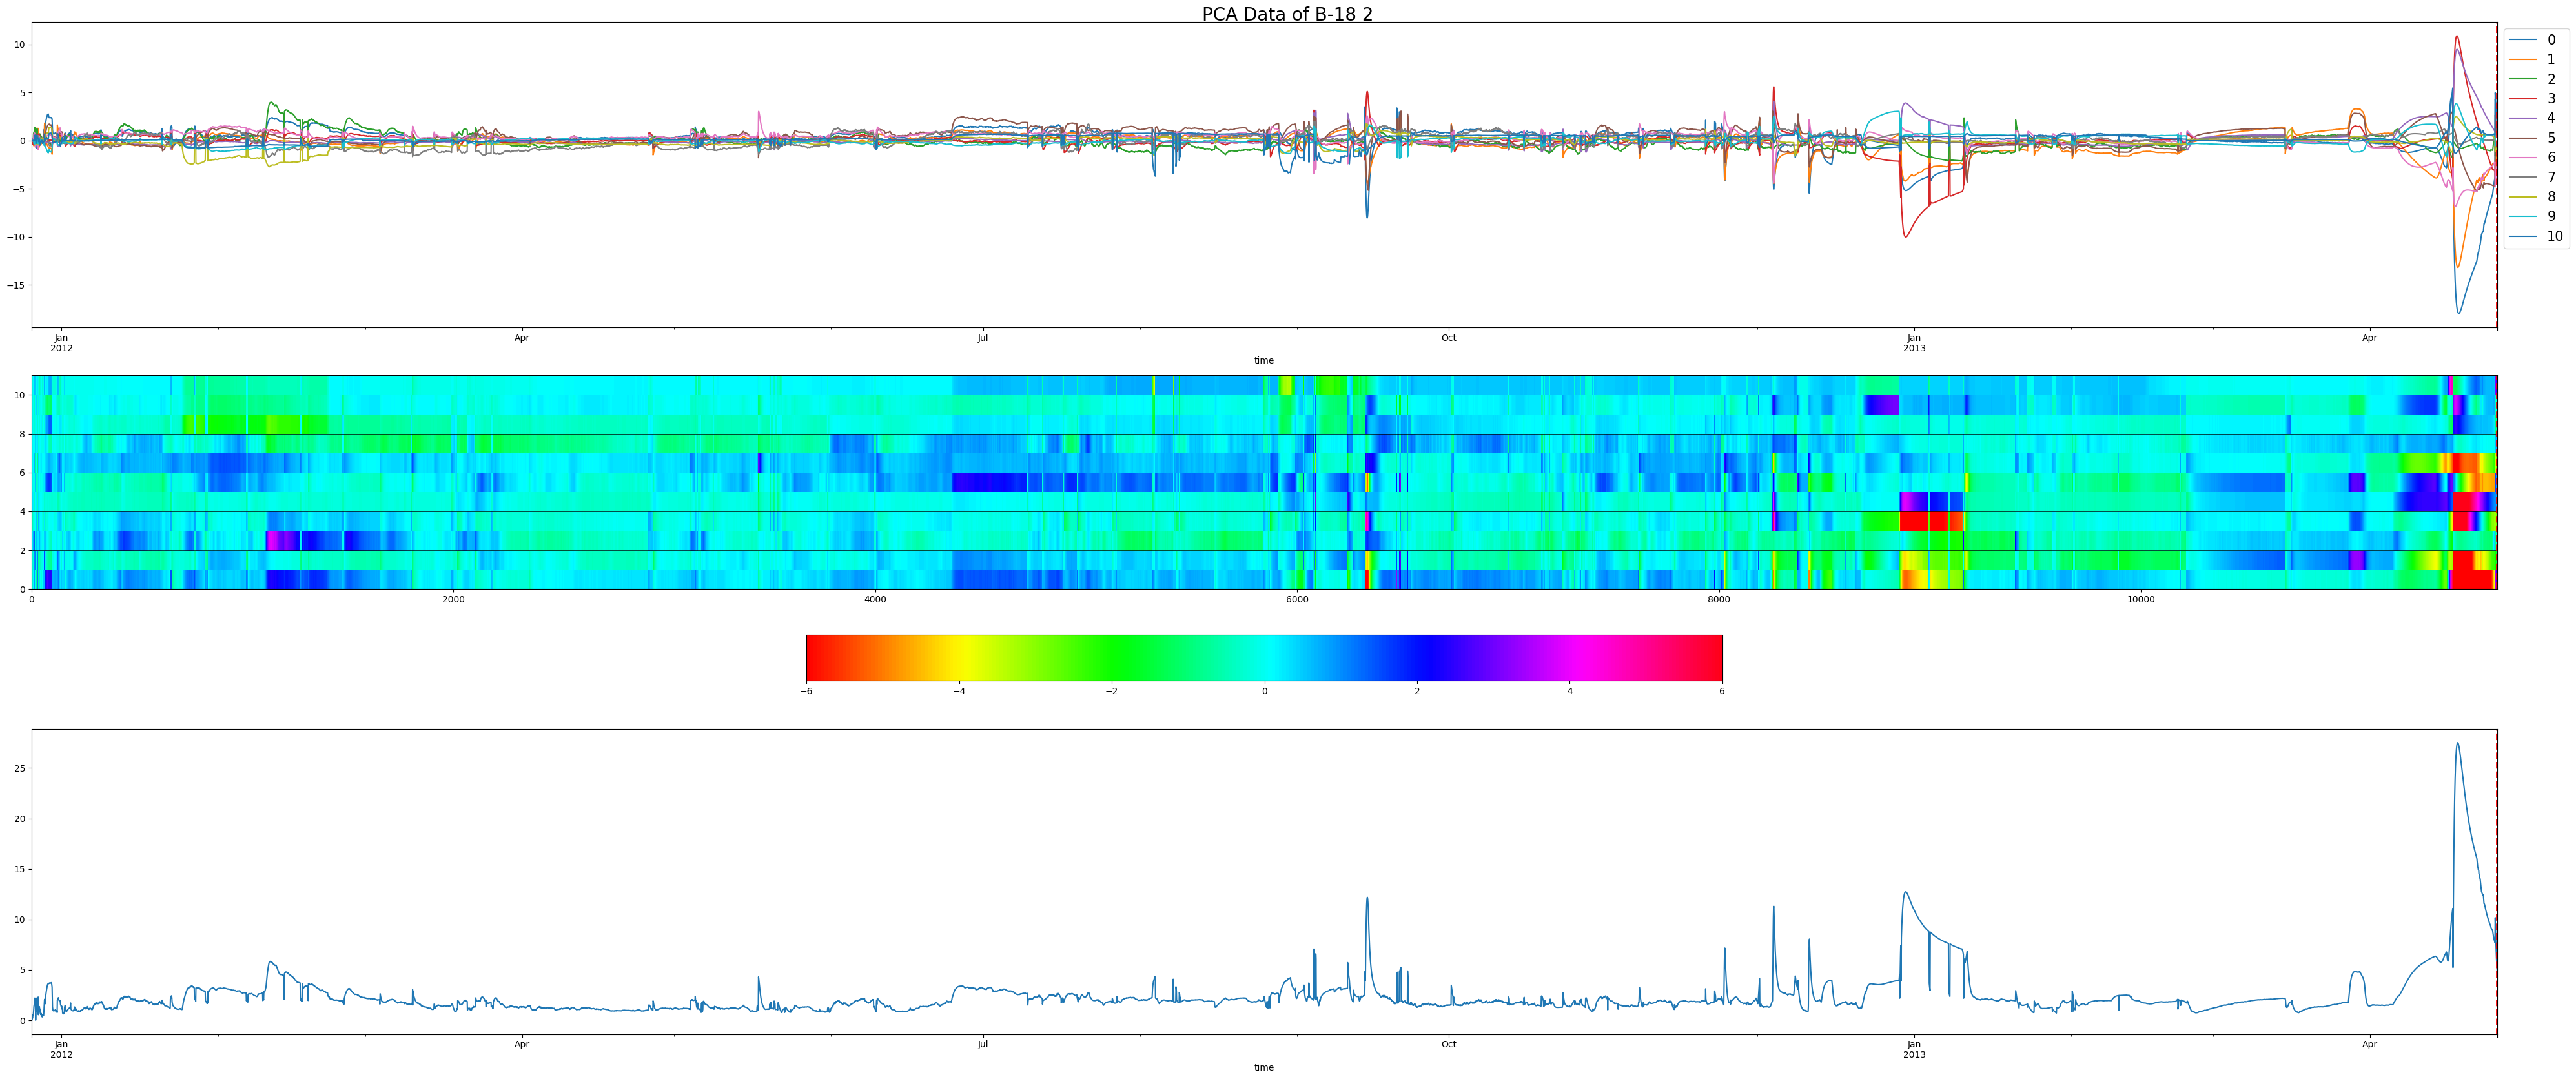

In [ ]:
pump = pumpList[0]

# pumpData = PCALF.loc[PCALF["Well Run"]==pump].copy()

# PCAHeaders = [i for i in range(0,componentsLF)]

pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()




li.PCAComponentsPlot(pumpData,pump,PCAHeaders)
plt.tight_layout()

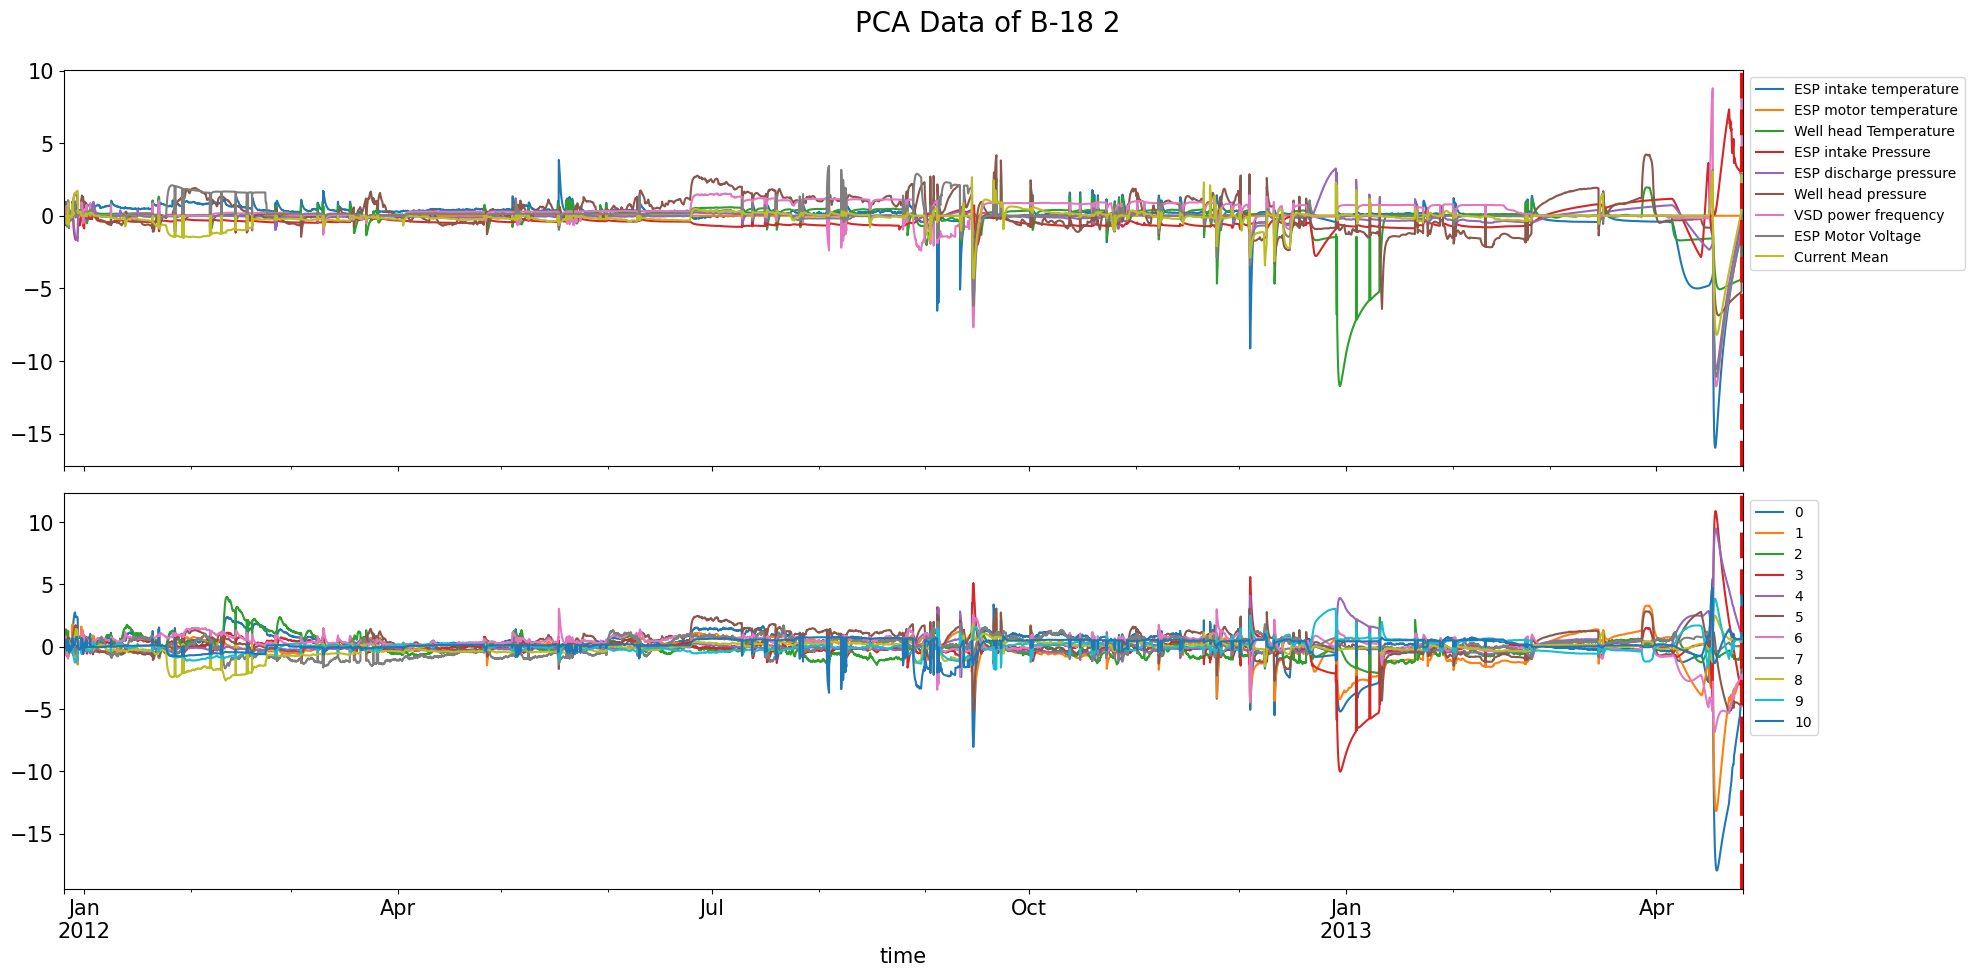

In [ ]:
pumpDataOriginal = entireData.loc[entireData["Well Run"]==pump].copy()

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean'
    #'ESP Vibration Module',
    #'ESP Power'
    ]

li.PCAComparisionPlot(pumpData,pumpDataOriginal,pump,PCAHeaders,Headers)
plt.savefig("../imagens_gerais/PCA_b_28_2.jpg")

7.5

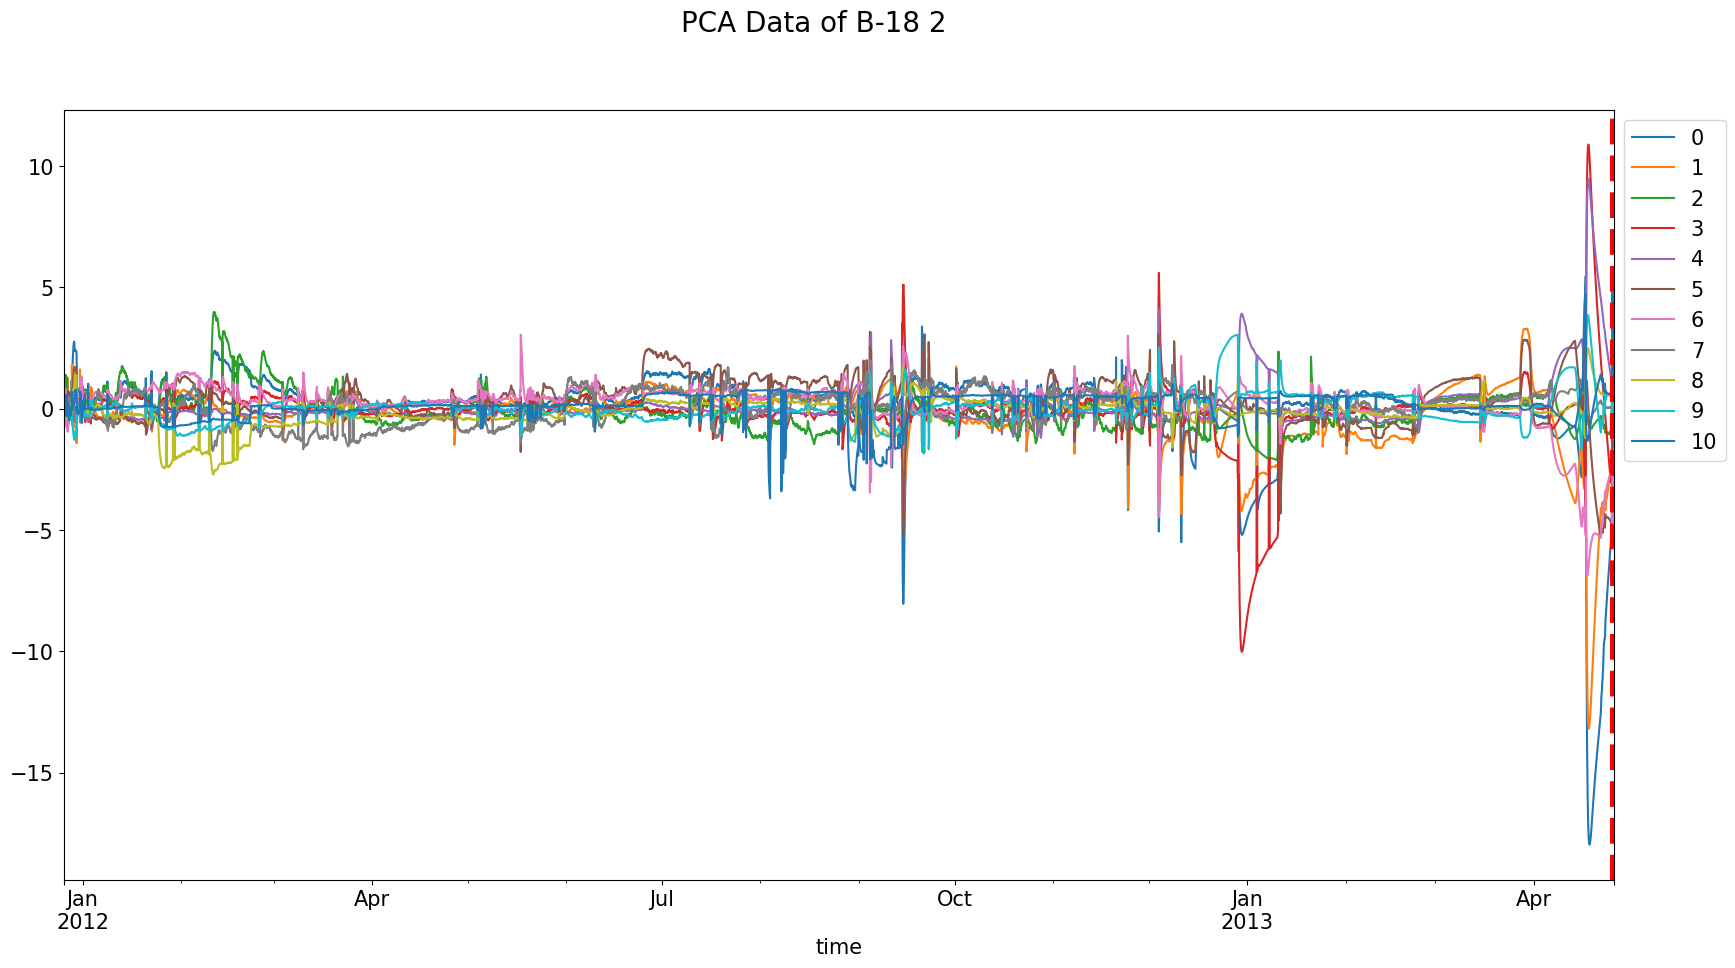

In [ ]:
pump = pumpList[0]
plt.rcParams['font.size'] = 15.0

pumpData = PCAdata.loc[PCAdata["Well Run"]==pump].copy()

fig, ax = plt.subplots(1,1, figsize=(20,10))

pumpData[PCAHeaders].plot(ax=ax)

ax.axvline(pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)
ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)

fig.suptitle("PCA Data of " + pump,fontsize=20);


factor = 0.5


plt.rcParams.update({
    'font.size': plt.rcParams['font.size'] * factor,
})

#fig.savefig("imagens/relatorio/PCAapplied")

plt.rcParams['font.size']

In [ ]:
import numpy as np
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([20,20,60])  # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")


Estatística qui-quadrado: 32.0000, p-valor: 0.0000
Rejeitamos H0: C ocorre significativamente mais do que o esperado.
